# World Cup 2026 Predictor - Live Validation

This notebook validates model predictions against already-played World Cup 2026 matches.

In [9]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from src.config import PROCESSED_DIR, RAW_DIR
from src.models.live_validation import validate_against_live

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Model

In [10]:
models_dir = PROCESSED_DIR / 'models'
model = joblib.load(models_dir / 'best_model.joblib')
feature_cols = joblib.load(models_dir / 'feature_columns.joblib')
print(f'Loaded model with {len(feature_cols)} features')

Loaded model with 80 features


## 2. Run Live Validation

In [11]:
results = validate_against_live(model, feature_cols)
if results:
    print(f'\nAccuracy (argmax): {results["accuracy_argmax"]:.4f}')
    print(f'Accuracy (draw threshold): {results["accuracy_threshold"]:.4f}')
    print(f'Log Loss: {results["log_loss"]:.4f}')
    print(f'Matches: {results["total_matches"]}')
    print(f'Correct (argmax): {results["correct_argmax"]}/{results["total_matches"]}')
    print(f'Correct (threshold): {results["correct_threshold"]}/{results["total_matches"]}')

2026-07-01 11:35:22,431 [INFO] worldcup: Validating model against live WC 2026 results...
2026-07-01 11:35:22,434 [INFO] worldcup: Found 79 played WC 2026 matches to validate against
2026-07-01 11:35:24,516 [INFO] worldcup: Live validation results:
2026-07-01 11:35:24,516 [INFO] worldcup:   Matches: 72
2026-07-01 11:35:24,516 [INFO] worldcup:   Accuracy (argmax): 0.6250
2026-07-01 11:35:24,516 [INFO] worldcup:   Accuracy (draw threshold 0.85): 0.6250
2026-07-01 11:35:24,517 [INFO] worldcup:   Log Loss: 0.8682
2026-07-01 11:35:24,519 [INFO] worldcup:   Saved to /Users/sithea/Documents/code/worldcup/data/processed/live_validation_report.csv
2026-07-01 11:35:24,519 [INFO] worldcup:   ✓ Mexico 2-0 South Africa | Pred: home_win (argmax: home_win) | Actual: home_win | H:0.73 D:0.18 A:0.09 | D/max: 0.24
2026-07-01 11:35:24,519 [INFO] worldcup:   ✓ South Korea 2-1 Czech Republic | Pred: home_win (argmax: home_win) | Actual: home_win | H:0.38 D:0.29 A:0.32 | D/max: 0.77
2026-07-01 11:35:24,520 


Accuracy (argmax): 0.6250
Accuracy (draw threshold): 0.6250
Log Loss: 0.8682
Matches: 72
Correct (argmax): 45/72
Correct (threshold): 45/72


## 3. Per-Match Analysis

In [12]:
if results and not results['results'].empty:
    df = results['results']
    print('Per-match predictions vs actual results:')
    print(df.to_string(index=False))

Per-match predictions vs actual results:
         home_team          away_team  home_score  away_score actual_outcome predicted_outcome predicted_argmax  prob_home_win  prob_draw  prob_away_win  draw_ratio  correct
            Mexico       South Africa           2           0       home_win          home_win         home_win       0.729119   0.177600       0.093281    0.243581     True
       South Korea     Czech Republic           2           1       home_win          home_win         home_win       0.383877   0.293679       0.322443    0.765034     True
            Canada Bosnia-Herzegovina           1           1           draw          home_win         home_win       0.584660   0.272552       0.142788    0.466172    False
     United States           Paraguay           4           1       home_win          home_win         home_win       0.397080   0.262253       0.340667    0.660453     True
             Qatar        Switzerland           1           1           draw          awa

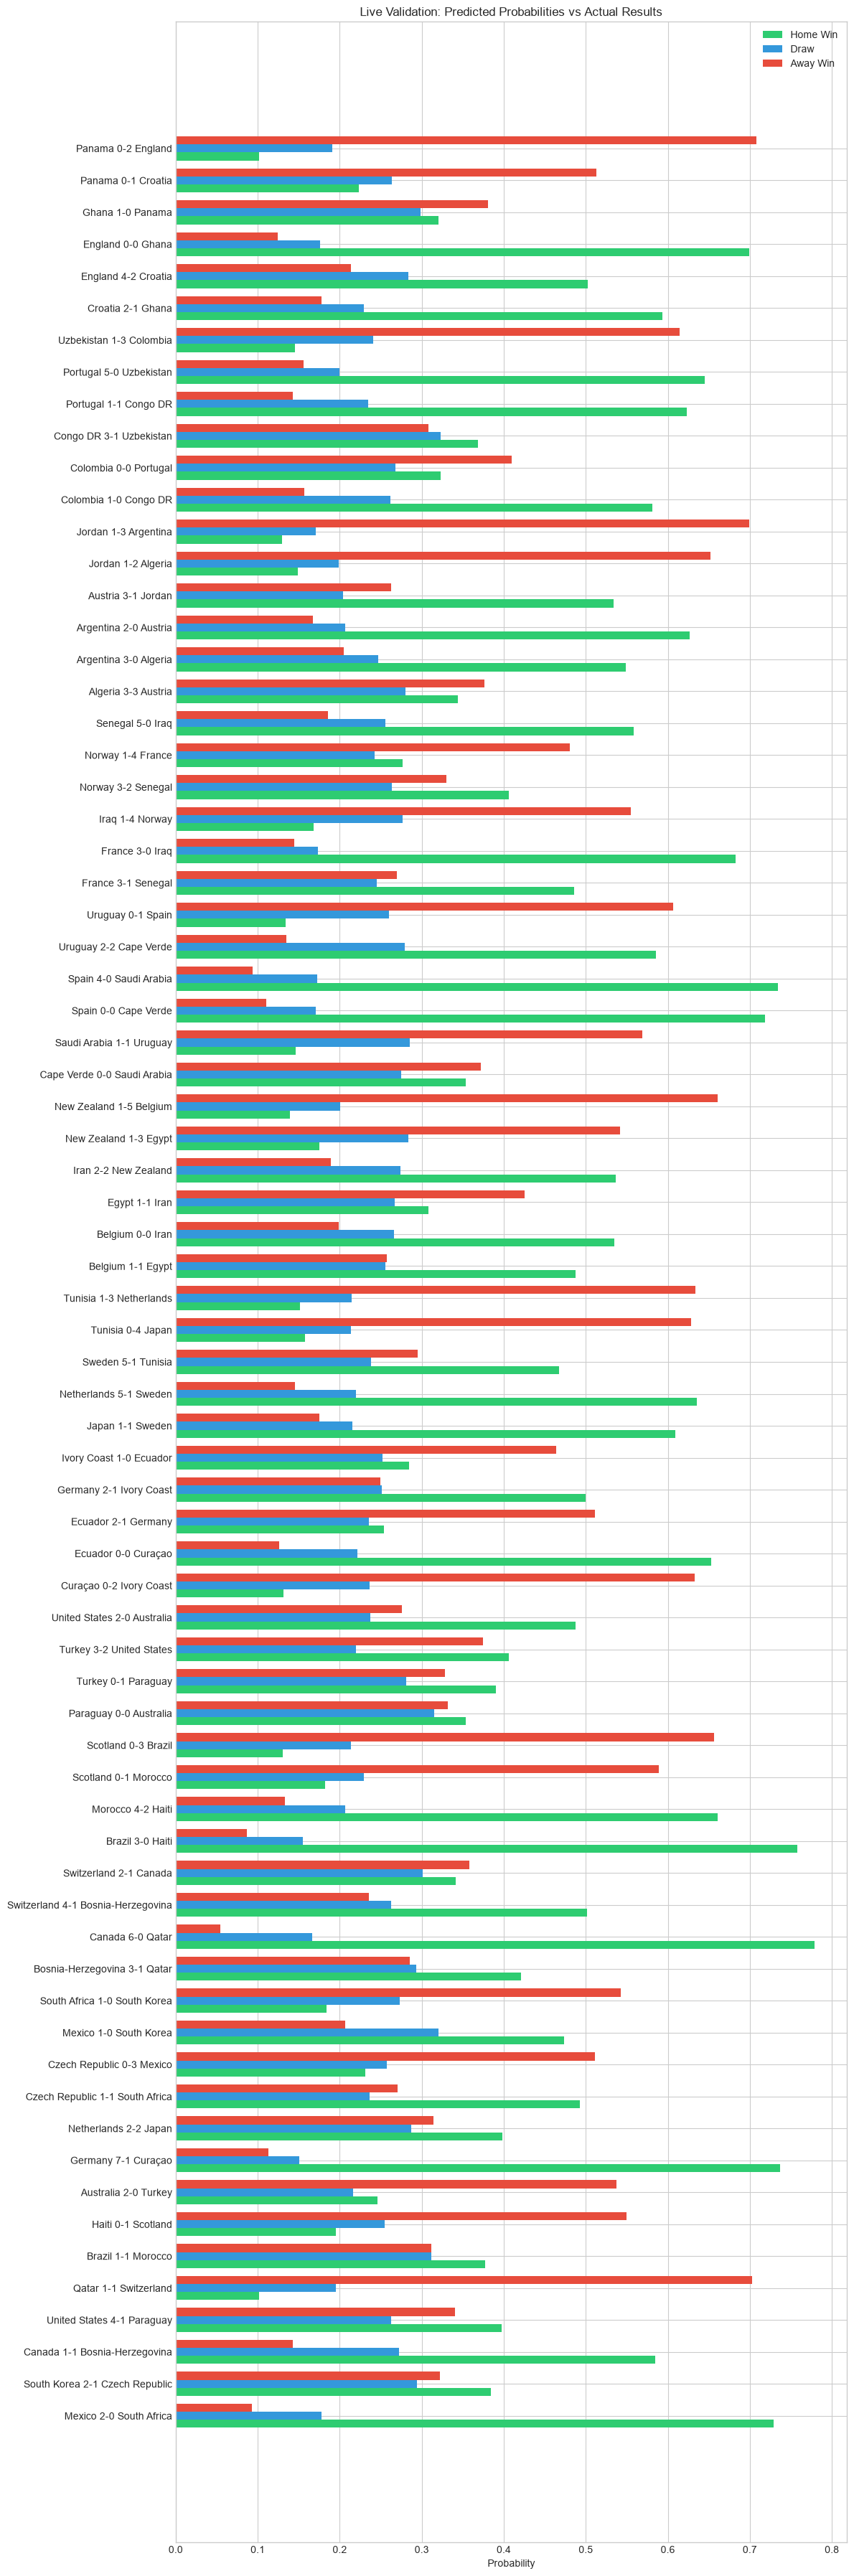

In [13]:
if results and not results['results'].empty:
    df = results['results']

    fig, ax = plt.subplots(figsize=(12, max(6, len(df) * 0.5)))

    y_pos = range(len(df))
    bar_width = 0.25

    ax.barh([y - bar_width for y in y_pos], df['prob_home_win'], bar_width, label='Home Win', color='#2ecc71')
    ax.barh(y_pos, df['prob_draw'], bar_width, label='Draw', color='#3498db')
    ax.barh([y + bar_width for y in y_pos], df['prob_away_win'], bar_width, label='Away Win', color='#e74c3c')

    labels = [f"{r['home_team']} {r['home_score']}-{r['away_score']} {r['away_team']}" for _, r in df.iterrows()]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Probability')
    ax.set_title('Live Validation: Predicted Probabilities vs Actual Results')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Confusion Analysis

In [14]:
if results and not results['results'].empty:
    df = results['results']

    correct = df['correct'].sum()
    total = len(df)
    incorrect = total - correct

    print(f'Correct predictions: {correct}/{total} ({correct/total*100:.1f}%)')
    print(f'Incorrect predictions: {incorrect}/{total} ({incorrect/total*100:.1f}%)')

    if incorrect > 0:
        wrong = df[~df['correct']]
        print(f'\nIncorrect predictions:')
        for _, r in wrong.iterrows():
            print(f'  {r["home_team"]} vs {r["away_team"]}: predicted {r["predicted_outcome"]}, actual {r["actual_outcome"]}')

Correct predictions: 45/72 (62.5%)
Incorrect predictions: 27/72 (37.5%)

Incorrect predictions:
  Canada vs Bosnia-Herzegovina: predicted home_win, actual draw
  Qatar vs Switzerland: predicted away_win, actual draw
  Brazil vs Morocco: predicted home_win, actual draw
  Australia vs Turkey: predicted away_win, actual home_win
  Netherlands vs Japan: predicted home_win, actual draw
  Czech Republic vs South Africa: predicted home_win, actual draw
  South Africa vs South Korea: predicted away_win, actual home_win
  Switzerland vs Canada: predicted away_win, actual home_win
  Turkey vs Paraguay: predicted home_win, actual away_win
  Ecuador vs Curaçao: predicted home_win, actual draw
  Ecuador vs Germany: predicted away_win, actual home_win
  Ivory Coast vs Ecuador: predicted away_win, actual home_win
  Japan vs Sweden: predicted home_win, actual draw
  Belgium vs Egypt: predicted home_win, actual draw
  Belgium vs Iran: predicted home_win, actual draw
  Egypt vs Iran: predicted away_win,

## 5. Round of 32 Predictions

Predictions for all 16 Round of 32 matches based on official FIFA bracket structure.
Matches that went to penalties are judged by who advanced, not the 90-min score.

In [15]:
import shutil
from src.features.build_2026_features import build_wc2026_features

# Compute group standings from live results
live_all = pd.read_csv(RAW_DIR / 'wc2026_results_live.csv')
live_all = live_all[live_all['home_score'].notna()].copy()
live_all['home_score'] = live_all['home_score'].astype(int)
live_all['away_score'] = live_all['away_score'].astype(int)
gm = live_all[live_all['group'].notna() & (live_all['group'] != 'R32')]

standings = {}
for grp in sorted(gm['group'].unique()):
    g = gm[gm['group'] == grp]
    teams = sorted(set(g['home_team']).union(set(g['away_team'])))
    table = {}
    for t in teams:
        table[t] = {'P': 0, 'W': 0, 'D': 0, 'L': 0, 'GF': 0, 'GA': 0, 'Pts': 0}
    for _, r in g.iterrows():
        h, a, hs, as_ = r['home_team'], r['away_team'], r['home_score'], r['away_score']
        table[h]['P'] += 1; table[a]['P'] += 1
        table[h]['GF'] += hs; table[h]['GA'] += as_
        table[a]['GF'] += as_; table[a]['GA'] += hs
        if hs > as_:
            table[h]['W'] += 1; table[a]['L'] += 1; table[h]['Pts'] += 3
        elif hs < as_:
            table[a]['W'] += 1; table[h]['L'] += 1; table[a]['Pts'] += 3
        else:
            table[h]['D'] += 1; table[a]['D'] += 1
            table[h]['Pts'] += 1; table[a]['Pts'] += 1
    sdf = pd.DataFrame(table).T
    sdf['GD'] = sdf['GF'] - sdf['GA']
    standings[grp] = sdf.sort_values(['Pts', 'GD', 'GF'], ascending=False)

W = {g: standings[g].index[0] for g in standings}
R = {g: standings[g].index[1] for g in standings}
T = {g: standings[g].index[2] for g in standings}

# Best 8 third-place teams
third_list = []
for grp, t in T.items():
    row = standings[grp].loc[t]
    third_list.append({'team': t, 'group': grp, 'points': row['Pts'], 'goal_diff': row['GD'], 'goals_for': row['GF']})
third_df = pd.DataFrame(third_list).sort_values(['points', 'goal_diff', 'goals_for'], ascending=False).reset_index(drop=True)
qualified_thirds = third_df.head(8)
print('Qualified third-place teams:')
print(qualified_thirds.to_string(index=False))
print(f'\nThird-place groups: {sorted(qualified_thirds["group"].tolist())}')

Qualified third-place teams:
              team group  points  goal_diff  goals_for
          Congo DR     K       4          1          4
            Sweden     F       4          0          7
           Ecuador     E       4          0          2
             Ghana     L       4          0          2
Bosnia-Herzegovina     B       4         -1          5
           Algeria     J       4         -2          5
          Paraguay     D       4         -2          2
           Senegal     I       3          2          8

Third-place groups: ['B', 'D', 'E', 'F', 'I', 'J', 'K', 'L']


In [16]:
# Official FIFA R32 bracket for third-place groups B, D, E, F, I, J, K, L
r32_matches = [
    (73, R['A'], R['B']),       # 2A vs 2B
    (74, W['E'], T['D']),       # 1E vs 3D
    (75, W['F'], R['C']),       # 1F vs 2C
    (76, W['C'], R['F']),       # 1C vs 2F
    (77, W['I'], T['F']),       # 1I vs 3F
    (78, R['E'], R['I']),       # 2E vs 2I
    (79, W['A'], T['E']),       # 1A vs 3E
    (80, W['L'], T['K']),       # 1L vs 3K
    (81, W['D'], T['B']),       # 1D vs 3B
    (82, W['G'], T['I']),       # 1G vs 3I
    (83, R['K'], R['L']),       # 2K vs 2L
    (84, W['H'], R['J']),       # 1H vs 2J
    (85, W['B'], T['J']),       # 1B vs 3J
    (86, W['J'], R['H']),       # 1J vs 2H
    (87, W['K'], T['L']),       # 1K vs 3L
    (88, R['D'], R['G']),       # 2D vs 2G
]

# Build features for all R32 matches
fixtures_df = pd.DataFrame([
    {'match_number': mn, 'date': '2026-06-30', 'home_team': h, 'away_team': a, 'group': 'R32'}
    for mn, h, a in r32_matches
])

# Load imputer
imputer = joblib.load(PROCESSED_DIR / 'models' / 'imputer.joblib')

orig_path = PROCESSED_DIR / 'wc2026_match_features.parquet'
backup_path = PROCESSED_DIR / 'wc2026_features_backup.parquet'
shutil.copy2(orig_path, backup_path)

r32_features = build_wc2026_features(fixtures_df=fixtures_df, include_live=True)

# Restore original features
shutil.copy2(backup_path, orig_path)
backup_path.unlink()

for col in feature_cols:
    if col not in r32_features.columns:
        r32_features[col] = 0.0

X_r32 = r32_features[feature_cols].values
if np.isnan(X_r32).any():
    X_r32 = imputer.transform(X_r32)

r32_proba = model.predict_proba(X_r32)
r32_preds = model.predict(X_r32)
LABEL = ['away_win', 'draw', 'home_win']

# Load played R32 results (with penalty winner)
played_r32 = {}
r32_live = live_all[live_all['group'].isna() | (live_all['group'] == 'R32')]
for _, r in r32_live.iterrows():
    winner = r['winner'] if 'winner' in live_all.columns and pd.notna(r.get('winner', '')) else None
    played_r32[(r['home_team'], r['away_team'])] = (int(r['home_score']), int(r['away_score']), winner)

print('=' * 105)
print('WC 2026 ROUND OF 32 — PREDICTIONS & RESULTS')
print('=' * 105)
correct_r32 = 0
total_r32 = 0
r32_rows = []
for i, (mn, h, a) in enumerate(r32_matches):
    p = r32_proba[i]
    pr = r32_preds[i]
    score = ''
    ok = ''
    key = (h, a)
    swap = (a, h)
    if key in played_r32:
        hs, as_, winner = played_r32[key]
        score = f'{hs}-{as_}'
        total_r32 += 1
        if winner is not None:
            pred_adv = h if pr == 2 else (a if pr == 0 else None)
            ok = 'Y' if pred_adv == winner else 'N'
        else:
            act = 2 if hs > as_ else (0 if hs < as_ else 1)
            ok = 'Y' if pr == act else 'N'
        if ok == 'Y':
            correct_r32 += 1
    elif swap in played_r32:
        hs, as_, winner = played_r32[swap]
        score = f'{hs}-{as_}'
        total_r32 += 1
        if winner is not None:
            pred_adv = h if pr == 2 else (a if pr == 0 else None)
            ok = 'Y' if pred_adv == winner else 'N'
        else:
            act = 2 if hs > as_ else (0 if hs < as_ else 1)
            ok = 'Y' if pr == act else 'N'
        if ok == 'Y':
            correct_r32 += 1
    mark = '✓' if ok == 'Y' else ('✗' if ok == 'N' else ' ')
    print(f'{mn:>3} {h[:20]:<22}{a[:20]:<22} H:{p[2]*100:>4.0f}% D:{p[1]*100:>4.0f}% A:{p[0]*100:>4.0f}%  {LABEL[pr]:<10} {score:<6} {mark}')
    r32_rows.append({
        'match_number': mn, 'home_team': h, 'away_team': a,
        'prob_home_win': p[2], 'prob_draw': p[1], 'prob_away_win': p[0],
        'predicted': LABEL[pr], 'score': score, 'correct': ok,
    })
print('=' * 105)
print(f'Played: {total_r32}  |  Correct: {correct_r32}  |  Accuracy: {correct_r32/max(total_r32,1)*100:.1f}%  |  Pending: {16 - total_r32}')

r32_results_df = pd.DataFrame(r32_rows)
r32_results_df.to_csv(PROCESSED_DIR / 'r32_validation_report.csv', index=False)

2026-07-01 11:35:24,987 [INFO] worldcup: Building WC 2026 match features...
2026-07-01 11:35:24,994 [INFO] worldcup: Loading all data sources...
2026-07-01 11:35:25,054 [INFO] worldcup:   Matches: 49477 rows
2026-07-01 11:35:25,056 [INFO] worldcup:   Shootouts: 678 rows
2026-07-01 11:35:25,105 [INFO] worldcup:   Rankings: 67492 rows
2026-07-01 11:35:25,106 [INFO] worldcup:   Current rankings: 20 rows
2026-07-01 11:35:25,107 [INFO] worldcup:   Continents: 104 rows
2026-07-01 11:35:25,109 [INFO] worldcup:   WC History: 117 rows
2026-07-01 11:35:25,110 [INFO] worldcup:   Live results: 79 rows
2026-07-01 11:35:25,111 [INFO] worldcup:   Squad quality: 48 teams
2026-07-01 11:35:25,282 [INFO] worldcup: Saved 16 WC 2026 match features to /Users/sithea/Documents/code/worldcup/data/processed/wc2026_match_features.parquet


WC 2026 ROUND OF 32 — PREDICTIONS & RESULTS
 73 South Africa          Canada                 H:  28% D:  33% A:  39%  away_win   0-1    ✓
 74 Germany               Paraguay               H:  54% D:  25% A:  21%  home_win   1-1    ✗
 75 Netherlands           Morocco                H:  30% D:  30% A:  40%  away_win   1-1    ✓
 76 Brazil                Japan                  H:  45% D:  30% A:  25%  home_win   2-1    ✓
 77 France                Sweden                 H:  62% D:  20% A:  17%  home_win   3-0    ✓
 78 Ivory Coast           Norway                 H:  29% D:  26% A:  45%  away_win   1-2    ✓
 79 Mexico                Ecuador                H:  40% D:  33% A:  27%  home_win   2-0    ✓
 80 England               Congo DR               H:  54% D:  28% A:  18%  home_win           
 81 United States         Bosnia-Herzegovina     H:  58% D:  22% A:  21%  home_win           
 82 Belgium               Senegal                H:  46% D:  31% A:  23%  home_win           
 83 Portugal    

In [17]:
# Combined summary: Group Stage + Round of 32
gs_correct = int(results['correct_argmax']) if results else 0
gs_total = int(results['total_matches']) if results else 0

print('COMBINED LIVE VALIDATION SUMMARY')
print('=' * 50)
print(f'Group Stage:  {gs_correct}/{gs_total} ({gs_correct/gs_total*100:.1f}%)  |  Log Loss: {results["log_loss"]:.3f}' if results else 'Group stage: N/A')
print(f'Round of 32:  {correct_r32}/{total_r32} ({correct_r32/max(total_r32,1)*100:.1f}%)')
print(f'Total:        {gs_correct + correct_r32}/{gs_total + total_r32} ({(gs_correct + correct_r32)/(gs_total + total_r32)*100:.1f}%)')
print('=' * 50)

COMBINED LIVE VALIDATION SUMMARY
Group Stage:  45/72 (62.5%)  |  Log Loss: 0.868
Round of 32:  6/7 (85.7%)
Total:        51/79 (64.6%)
